<a href="https://colab.research.google.com/github/adityakaldhone09/dog-vs-cat-cnn-classifier/blob/main/CNN_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Combined code from the notebook

# From cell wcmVSNyYwCmZ
import kagglehub

# Download latest version
path = kagglehub.dataset_download("salader/dogs-vs-cats")

print("Path to dataset files:", path)

# From cell TcuqCCk4txRC
# Note: This part with kaggle.json might need adjustment based on how the script is run outside Colab
# If running locally, you might need to handle API key differently
import os
if not os.path.exists('~/.kaggle'):
    os.makedirs('~/.kaggle')
# Make sure kaggle.json is in the same directory as this script or provide the full path
# !cp kaggle.json ~/.kaggle/ # This line needs manual handling outside Colab

# From cell 8_6PNwuWtwrz
# Note: This uses the kaggle command-line tool, which requires Kaggle API to be set up
# If running locally, ensure you have the Kaggle API installed and configured
# !kaggle datasets download -d salader/dogs-vs-cats # This line needs manual handling outside Colab

# From cell VUZ1WYJawi1O
import zipfile
zip_ref = zipfile.ZipFile('/content/dogs-vs-cats.zip','r')
zip_ref.extractall('/content')
zip_ref.close()

# From cell A3G5GGQ2w5NU
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
import matplotlib.pyplot as plt
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, BatchNormalization, Dropout

# From cell 8snS_Vcqxfm2
# Generators
train_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/train',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (256, 256)
)
# All the size of images should be same
validation_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/test',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (256, 256)
)

# From cell REY_niLl23CJ
# Normalize The images
def process(image, label):
  image = tf.cast(image/255, tf.float32)
  return image, label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

# From cell UBH5FQ7n3X7r
#Create CNN Model

model = Sequential()

model.add(Conv2D(32, kernel_size=(3,3), padding = 'valid', activation = 'relu', input_shape = (256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides = 2, padding= 'valid'))

model.add(Conv2D(64, kernel_size = (3,3), padding = 'valid', activation = 'relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides =2, padding = 'valid'))

model.add(Conv2D(128, kernel_size = (3,3), padding = 'valid', activation = 'relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides = 2, padding = 'valid'))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1, activation='sigmoid'))

# From cell SqghZ1dgDH2F
# Summary of the Model (Architecture)
model.summary()

# From cell s71bP4M5DfmL
model.compile(optimizer='adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

# From cell aJD9eUMOD1m4
# Training the model
history = model.fit(train_ds, epochs = 10, validation_data = validation_ds)

# From cell A3ELcndWG63t
# Plot on Train vs Validation
# import matplotlib.pyplot as plt # Already imported earlier

plt.plot(history.history['accuracy'], color = 'red', label = 'train')
plt.plot(history.history['val_accuracy'], color = 'blue', label = 'validation')
plt.legend()
plt.show()

# From cell hu1gZW13ITvq
# After making some changes
plt.plot(history.history['loss'], color = 'red', label = 'train')
plt.plot(history.history['val_loss'], color = 'blue', label = 'validation')
plt.title("Loss Calculation (Train vs validation)")
plt.legend()
plt.show()

# From cell x7RBfFvyIg1Z
# import cv2 # Need to install opencv-python
# import matplotlib.pyplot as plt # Already imported earlier

# test_img = cv2.imread('/content/dog.jpg')

# test_img_rgb = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
# plt.imshow(test_img_rgb)
# plt.show()

# From cell 2dUg-jlvLxc4
# test_img.shape # This is just an output, no code needed

# From cell Y3ygVvk4KXc4
# test_img = cv2.resize(test_img,(256,256)) # This is part of the prediction process, will include in a function

# From cell y7_4rSYLMESP
# test_input = test_img.reshape((1,256,256,3)) # This is part of the prediction process, will include in a function

# From cell mP_gIk6mMP8f
# Prediction
# result = model.predict(test_input) # This is part of the prediction process, will include in a function
# print(result)

# From cell PT6Sl6h9J2up and yt0VX6raJ7-x
# Note: tkinter is a GUI library and might not work directly in some environments like Colab notebooks.
# If you need a GUI, consider running this code as a standalone Python script on a system with a display.
# The pip install commands should be run in a terminal before executing the script.
# pip install tkinter # Not available as a package
# pip install pillow
# pip install tensorflow # or torch

# From cell PIdYXURxJvT3
# import tkinter as tk # Commented out as it requires a display
# from tkinter import filedialog
# from tkinter import Label, Button, Canvas
# from PIL import Image, ImageTk
# import numpy as np

# Placeholder for Your Model Integration
# It's recommended to have a separate python file for your model logic
# For example, a file named `model_loader.py`

# def load_trained_model(model_path):
#     """Loads the pre-trained CNN model."""
#     # model = load_model(model_path)
#     # return model
#     pass

# def predict_image(model, image_path):
#     """Predicts if the image is a cat or a dog."""
#     # try:
#     #     img = image.load_img(image_path, target_size=(150, 150))
#     #     img_array = image.img_to_array(img)
#     #     img_array = np.expand_dims(img_array, axis=0)
#     #
#     #     # Preprocess the image (e.g., scaling)
#     #     img_array /= 255.0
#     #
#     #     # Make a prediction
#     #     prediction = model.predict(img_array)
#     #
#     #     if prediction[0] > 0.5:
#     #         return "Dog"
#     #     else:
#     #         return "Cat"
#     # except Exception as e:
#     #     return f"Error: {e}"
#     # A dummy prediction for UI testing
#     return "Dog" if np.random.rand() > 0.5 else "Cat"

# --- Main Application Class ---

# class CatDogClassifierApp: # Commented out as it requires a display
#     def __init__(self, root):
#         self.root = root
#         self.root.title("Cat or Dog? | CNN Classifier")
#         self.root.geometry("500x500")

#         self.model = None # To hold the loaded model
#         # self.model = load_trained_model('path/to/your/model.h5') # Uncomment to load model

#         # --- Widgets ---
#         self.title_label = Label(root, text="Image Classifier: Cat or Dog", font=("Helvetica", 16))
#         self.title_label.pack(pady=10)

#         self.upload_button = Button(root, text="Upload Image", command=self.upload_image)
#         self.upload_button.pack(pady=10)

#         self.image_canvas = Canvas(root, width=300, height=300, bg="lightgrey")
#         self.image_canvas.pack()

#         self.classify_button = Button(root, text="Classify", command=self.classify_image, state=tk.DISABLED)
#         self.classify_button.pack(pady=10)

#         self.result_label = Label(root, text="", font=("Helvetica", 14, "bold"))
#         self.result_label.pack(pady=20)

#         self.image_path = None
#         self.image_tk = None

#     def upload_image(self):
#         """Opens a file dialog to select an image."""
#         self.image_path = filedialog.askopenfilename(
#             filetypes=[("Image Files", "*.png *.jpg *.jpeg *.gif *.bmp")]
#         )
#         if self.image_path:
#             # Display the image on the canvas
#             image = Image.open(self.image_path)
#             image = image.resize((300, 300), Image.LANCZOS)
#             self.image_tk = ImageTk.PhotoImage(image)

#             self.image_canvas.create_image(150, 150, image=self.image_tk)
#             self.classify_button['state'] = tk.NORMAL
#             self.result_label['text'] = ""

#     def classify_image(self):
#         """Classifies the uploaded image and displays the result."""
#         if self.image_path and self.model:
#             # prediction = predict_image(self.model, self.image_path)
#             # self.result_label['text'] = f"Prediction: {prediction}"
#             pass # Use this for the actual model
#         elif self.image_path:
#             # This is a dummy classification for UI testing
#             # Replace this with your model's prediction logic
#             # prediction = predict_image(None, self.image_path)
#             # self.result_label['text'] = f"Prediction: {prediction}"
#             self.result_label['text'] = "Model not loaded. This is a dummy result."


# if __name__ == "__main__": # Commented out as it requires a display
#     root = tk.Tk()
#     app = CatDogClassifierApp(root)
#     root.mainloop()

# Function to predict a single image
def predict_single_image(model, image_path):
    """Predicts if the image is a cat or a dog using the trained model."""
    try:
        img = cv2.imread(image_path)
        img = cv2.resize(img, (256, 256))
        img_input = img.reshape((1, 256, 256, 3))
        # Normalize the image
        img_input = tf.cast(img_input/255, tf.float32)

        prediction = model.predict(img_input)

        if prediction[0] > 0.5:
            return "Dog"
        else:
            return "Cat"
    except Exception as e:
        return f"Error: {e}"

# Example usage of the prediction function (assuming you have a test image)
# test_image_path = '/content/dog.jpg' # Replace with your test image path
# prediction_result = predict_single_image(model, test_image_path)
# print(f"The image is predicted to be a: {prediction_result}")

In [ ]:
import kagglehub

path = kagglehub.dataset_download("salader/dogsvscats")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'dogsvscats' dataset.
Path to dataset files: /kaggle/input/dogsvscats


In [ ]:
!mkdir ~p ~/.kaggle
!cp kaggle.json ~/.kaggle/

mkdir: cannot create directory ‘/root/.kaggle’: File exists


In [ ]:
!kaggle datasets download salader/dogsvscats

Dataset URL: https://www.kaggle.com/datasets/salader/dogsvscats
License(s): unknown
100% 1.06G/1.06G [00:14<00:00, 77.8MB/s]



In [ ]:
import zipfile
zip_ref = zipfile.ZipFile('/content/dogsvscats.zip','r')
zip_ref.extractall('/content')
zip_ref.close()

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
import matplotlib.pyplot as plt
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, BatchNormalization, Dropout

In [ ]:
# Generators
train_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/train',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (256, 256)
)
# All the size of images should be same
validation_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/test',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (256, 256)
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [ ]:
# Normalize The images
def process(image, label):
  image = tf.cast(image/255, tf.float32)
  return image, label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [ ]:
#Create CNN Model

model = Sequential()

model.add(Conv2D(32, kernel_size=(3,3), padding = 'valid', activation = 'relu', input_shape = (256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides = 2, padding= 'valid'))

model.add(Conv2D(64, kernel_size = (3,3), padding = 'valid', activation = 'relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides =2, padding = 'valid'))

model.add(Conv2D(128, kernel_size = (3,3), padding = 'valid', activation = 'relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides = 2, padding = 'valid'))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Summary of the Model (Architecture)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,193 (56.64 MB)

 Trainable params: 14,847,745 (56.64 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
model.compile(optimizer='adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

In [ ]:
history = model.fit(train_ds, epochs = 10, validation_data = validation_ds)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 71s 91ms/step - accuracy: 0.6044 - loss: 1.1318 - val_accuracy: 0.6268 - val_loss: 0.6343
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 91ms/step - accuracy: 0.7152 - loss: 0.5555 - val_accuracy: 0.7592 - val_loss: 0.5165
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 93ms/step - accuracy: 0.7775 - loss: 0.4741 - val_accuracy: 0.7694 - val_loss: 0.4768
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 94ms/step - accuracy: 0.8166 - loss: 0.4083 - val_accuracy: 0.7820 - val_loss: 0.4895
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 62s 99ms/step - accuracy: 0.8500 - loss: 0.3436 - val_accuracy: 0.7738 - val_loss: 0.5193
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 100ms/step - accuracy: 0.8934 - loss: 0.2528 - val_accuracy: 0.7768 - val_loss: 0.5129
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 62s 98ms/step - accuracy: 0.9315 - loss: 0.1740 - val_accuracy: 0.8012 - val_loss: 0.6252
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 94ms/step - accuracy: 0.9585 - loss: 0.1117 -

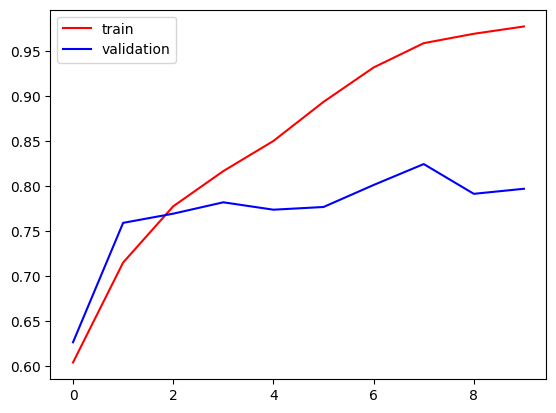

In [ ]:
# Plot on Train vs Validation
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], color = 'red', label = 'train')
plt.plot(history.history['val_accuracy'], color = 'blue', label = 'validation')
plt.legend()
plt.show()

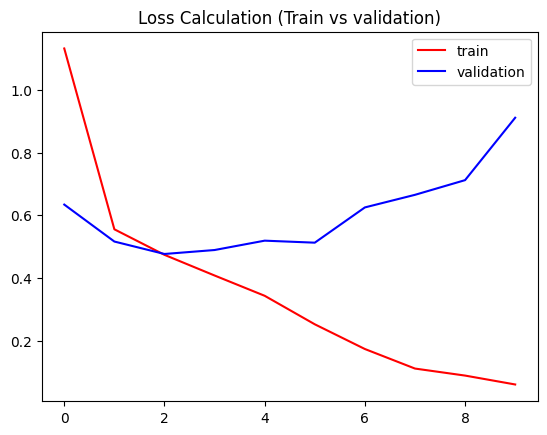

In [ ]:
# After making some changes
plt.plot(history.history['loss'], color = 'red', label = 'train')
plt.plot(history.history['val_loss'], color = 'blue', label = 'validation')
plt.title("Loss Calculation (Train vs validation)")
plt.legend()
plt.show()

Ways to Reduce Overfitting :
* Add More data
* DataAugmentation
-L1,L2 Regularizer
-Dropout
-Batch Norm
-Reduce complexity

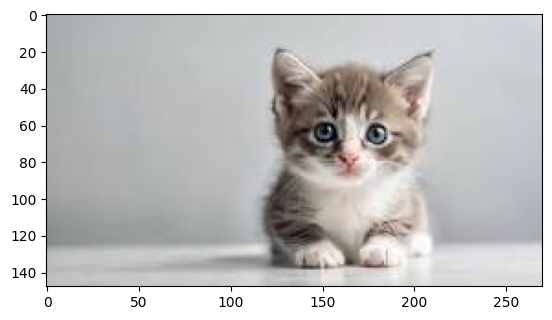

In [ ]:
import cv2
import matplotlib.pyplot as plt

test_img = cv2.imread('/content/Test_cat.jpeg')

test_img_rgb = cv2.cvtColor(test_img, cv2.COLOR_BGR2RGB)
plt.imshow(test_img_rgb)
plt.show()

In [ ]:
test_img.shape

(148, 270, 3)

In [ ]:
test_img = cv2.resize(test_img,(256,256))

In [ ]:
test_input = test_img.reshape((1,256,256,3))

In [ ]:
model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


array([[0.]], dtype=float32)

-----------------------------------------------------------------------

> **END...!**

